In [259]:
 # usual imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# NLP-specific imports

# CountVectorizer => the most simple vectorizing method for text data
from sklearn.feature_extraction.text import CountVectorizer

# import the multinomial Naive-Bayes (supports more than 2 outcomes too)
from sklearn.naive_bayes import MultinomialNB

In [ ]:
# load the data and see the contents
# we need to clean this dataset as here is too many columns.
# out tasget variable is "research_type" lets's check it out.
# The dataset is very big and i  couldn't commit it to GitHub,
# so i will save here the cleaned dataset here. 
df = pd.read_csv("biomedical_research_abstracts_2024_2026.csv")
df.tail()

,pmid,title,abstract,abstract_words,journal,pub_year,pub_month,pub_month_num,month_year,doi,authors_count,country,research_type,keywords,major_topic,language,open_access
126827,37015487,The Risks of Ranking: Revisiting Graphical Per...,Graphical perception studies typically measure...,209,IEEE transactions on visualization and compute...,2024,Mar,3,Mar-2024,10.1109/TVCG.2022.3226463,8,Unknown,"Journal Article; Research Support, U.S. Gov't,...",Humans; Individuality; Bayes Theorem; Computer...,Individuality,eng,False
126828,37015450,Personalized Audio-Driven 3D Facial Animation ...,We present a learning-based approach for gener...,198,IEEE transactions on visualization and compute...,2024,Mar,3,Mar-2024,10.1109/TVCG.2022.3230541,4,Unknown,"Journal Article; Research Support, U.S. Gov't,...",Humans; Computer Graphics; Face; Speech,Computer Graphics,eng,False
126829,36711949,Functional characterization of the language ne...,How do polyglots-individuals who speak five or...,198,bioRxiv : the preprint server for biology,2024,Jan,1,Jan-2024,10.1101/2023.01.19.524657,8,MA 02139,Preprint; Journal Article,NaN,NaN,eng,True
126830,36455093,Marching Windows: Scalable Mesh Generation for...,Volumetric data abounds in medical imaging and...,231,IEEE transactions on visualization and compute...,2024,Mar,3,Mar-2024,10.1109/TVCG.2022.3225526,7,Unknown,Journal Article,NaN,NaN,eng,True
126831,36346866,A Survey of Smooth Vector Graphics: Recent Adv...,The field of smooth vector graphics explores t...,195,IEEE transactions on visualization and compute...,2024,Mar,3,Mar-2024,10.1109/TVCG.2022.3220575,2,Unknown,Journal Article,NaN,NaN,eng,False


In [261]:
# here and further sometimes I used AI:
# select target column
target = df["research_type"]

# split labels by ";"
split_labels = target.str.split(";")

# flatten lists into rows
exploded_labels = split_labels.explode()

# remove extra spaces
clean_labels = exploded_labels.str.strip()

# count frequency
counts = clean_labels.value_counts()

# get top 8
top_8 = counts.head(8)

# print results
print("Top Research Types:")
for label, count in top_8.items():
    print(f"{label}: {count}")

Top Research Types:
Journal Article: 126347
Research Support, Non-U.S. Gov't: 11774
Review: 10234
Case Reports: 4968
Systematic Review: 2531
Research Support, N.I.H., Extramural: 2187
Randomized Controlled Trial: 1659
Meta-Analysis: 1494


In [262]:
# I will map the target variable into 5 categories: Journal Article, Research Support, Review, Case Report, and Other.
# I chose partically these categories beacuse they all have more than 4 000 rows, 
# so we will have enough data for each category. 
# Mapping function to categorize research types
def categorize_research_type(research_type):
    research_type_lower = str(research_type).lower().strip()
    
    if "journal" in research_type_lower:
        return "Journal Article"
    elif "research support" in research_type_lower:
        return "Research Support"
    elif "review" in research_type_lower:  # catches both "Review" and "Systematic Review"
        return "Review"
    elif "case report" in research_type_lower or "case reports" in research_type_lower:
        return "Case Reports"
    else:
        return "Other"

# Apply the improved categorization
df['research_type_cleaned'] = df['research_type'].str.split(';').apply(
    lambda x: [categorize_research_type(label.strip()) for label in x]
)

# Check the distribution
df['research_type_cleaned'].explode().value_counts()

research_type_cleaned
Journal Article     126352
Research Support     14568
Review               13187
Other                 9836
Case Reports          4968
Name: count, dtype: int64

In [263]:
# Now we have not ballanced target variable, let's drop rows with only "Other" category. 
df.head()

,pmid,title,abstract,abstract_words,journal,pub_year,pub_month,pub_month_num,month_year,doi,authors_count,country,research_type,keywords,major_topic,language,open_access,research_type_cleaned
0,41869676,"The genome sequence of the bloodfluke planorb,...",We present a genome assembly from an individua...,57,Wellcome open research,2024,Unknown,0,Unknown-2024,10.12688/wellcomeopenres.22819.2,7,UK,Journal Article,NaN,NaN,eng,True,[Journal Article]
1,41841041,An exploratory study of critical incidents wit...,Leadership changes within public organizations...,250,F1000Research,2024,Unknown,0,Unknown-2024,10.12688/f1000research.142942.2,4,Indonesia,Journal Article,Leadership; Humans; Anxiety; Organizational In...,Leadership,eng,True,[Journal Article]
2,41797731,From Mary Shelley to Netflix: a Pan-European p...,Scientific knowledge of the human brain has ca...,244,Frontiers in neuroscience,2024,Unknown,0,Unknown-2024,10.3389/fnins.2024.1278640,2,Spain,Journal Article,NaN,NaN,eng,True,[Journal Article]
3,41726542,Improving electronic health record processing ...,Large language models (LLMs) excel in natural ...,134,AMIA ... Annual Symposium proceedings. AMIA Sy...,2024,Unknown,0,Unknown-2024,NaN,4,USA,Journal Article,Natural Language Processing; Electronic Health...,Natural Language Processing,eng,True,[Journal Article]
4,41726541,Developing a User-Centered Mobile Application ...,This study is part of the OsteoPorotic fracTur...,136,AMIA ... Annual Symposium proceedings. AMIA Sy...,2024,Unknown,0,Unknown-2024,NaN,13,USA,Journal Article,Mobile Applications; Humans; Skilled Nursing F...,Mobile Applications,eng,True,[Journal Article]


In [264]:
# Filter out rows with "Other" category AND remove "Other" from lists
# with help of ChatGPT
df['research_type_cleaned'] = df['research_type_cleaned'].apply(
    lambda x: [cat for cat in x if cat != "Other"]
)
df = df[df["research_type_cleaned"].apply(lambda x: len(x) > 0)].reset_index(drop=True)

In [265]:
# Explode and count the cleaned categories
df['research_type_cleaned'].explode().value_counts()

research_type_cleaned
Journal Article     126352
Research Support     14568
Review               13187
Case Reports          4968
Name: count, dtype: int64

In [266]:
df.describe()

,pmid,abstract_words,pub_year,pub_month_num,authors_count
count,1.264010e+05,126401.000000,126401.000000,126401.000000,126401.000000
mean,3.904831e+07,224.542939,2024.244389,2.814780,7.162285
std,1.285269e+06,70.577069,0.524054,3.122385,12.260899
min,3.343327e+07,50.000000,2024.000000,0.000000,0.000000
25%,3.821509e+07,179.000000,2024.000000,1.000000,4.000000
50%,3.828137e+07,224.000000,2024.000000,1.000000,6.000000
75%,3.989876e+07,261.000000,2024.000000,4.000000,9.000000
max,4.188182e+07,998.000000,2026.000000,12.000000,2932.000000


In [267]:
# Now we have a problem that each row may contain few categories, so we cannot downsample each category to 4000 rows. 
# We need to explode the list of categories into separate rows (one row per category) and then balance all categories to exactly 4000 rows each by downsampling.
# Explode the list of categories into separate rows (one row per category) - ChatGPT help to explode.
df_exploded = df.copy()
df_exploded['research_type_cleaned'] = df_exploded['research_type_cleaned'].apply(lambda x: x if isinstance(x, list) else [x])
df_exploded = df_exploded.explode('research_type_cleaned').reset_index(drop=True)


In [268]:
# So we have increased amount of rows.
df_exploded.describe()

,pmid,abstract_words,pub_year,pub_month_num,authors_count
count,1.590750e+05,159075.000000,159075.000000,159075.000000,159075.000000
mean,3.898438e+07,222.037800,2024.226748,2.761905,7.146975
std,1.257860e+06,71.181995,0.510481,3.049888,11.208033
min,3.343327e+07,50.000000,2024.000000,0.000000,0.000000
25%,3.821164e+07,175.000000,2024.000000,1.000000,4.000000
50%,3.827696e+07,221.000000,2024.000000,1.000000,6.000000
75%,3.984033e+07,259.000000,2024.000000,4.000000,9.000000
max,4.188182e+07,998.000000,2026.000000,12.000000,2932.000000


In [269]:
# Now balance all categories to exactly 4000 rows each by downsampling (ChatGPT helped here)
def balance_categories(df, target_count=4000):
    categories = df['research_type_cleaned'].unique()
    balanced_dfs = []
    
    for category in categories:
        category_rows = df[df['research_type_cleaned'] == category]
        
        if len(category_rows) > target_count:
            category_rows = category_rows.sample(n=target_count, random_state=42)
        
        balanced_dfs.append(category_rows)
    
    return pd.concat(balanced_dfs).reset_index(drop=True)

df = balance_categories(df_exploded, target_count=4000)

In [270]:
# Check the distribution - should now have exactly 4000 rows each
# great, now it works. Before exploding I got very small amount of rows for "Case Reports" and for "Research Support".
df['research_type_cleaned'].value_counts()

research_type_cleaned
Journal Article     4000
Review              4000
Case Reports        4000
Research Support    4000
Name: count, dtype: int64

In [271]:
# let's define labels in althabatical order:
labels = ["Case Reports", "Journal Article", "Research Support", "Review"]  

In [272]:
df.head()

,pmid,title,abstract,abstract_words,journal,pub_year,pub_month,pub_month_num,month_year,doi,authors_count,country,research_type,keywords,major_topic,language,open_access,research_type_cleaned
0,38175852,Effect of non-invasive neuromodulation techniq...,VCI is a severe public health problem facing t...,238,PloS one,2024,Unknown,0,Unknown-2024,10.1371/journal.pone.0284447,8,P R China,Journal Article,Bayes Theorem; China; Systematic Reviews as To...,NaN,eng,True,Journal Article
1,38298713,Experimental evaluation of transition rate of ...,Using a perfect single crystal as a neutron fi...,179,Heliyon,2024,Jan,1,Jan-2024,10.1016/j.heliyon.2024.e24160,6,Iran,Journal Article,NaN,NaN,eng,True,Journal Article
2,39867692,Aortoiliac arterial thrombosis and renal arter...,Multisystem inflammatory syndrome in neonates ...,296,Frontiers in pediatrics,2024,Unknown,0,Unknown-2024,10.3389/fped.2024.1474192,6,Thailand,Case Reports; Journal Article,NaN,NaN,eng,True,Journal Article
3,37916613,Evaluation of sleep health documentation and s...,"Sleep health is linked to pain, function, and ...",256,"PM & R : the journal of injury, function, and ...",2024,Jul,7,Jul-2024,10.1002/pmrj.13100,5,USA,Journal Article,Humans; Retrospective Studies; Male; Musculosk...,Musculoskeletal Diseases,eng,False,Journal Article
4,37604001,Changes in flavor and biological activities of...,This study aimed to elucidate how the Maillard...,148,Food chemistry,2024,Jan,1,Jan-2024,10.1016/j.foodchem.2023.137138,9,China,Journal Article,"Maillard Reaction; Chromatography, Liquid; Shi...",Maillard Reaction,eng,False,Journal Article


In [273]:
# that is very long title. I wanted to merge title and abstract, but it doesn't make any sense to have so long text.
# So, i will keep only "title" column as text data and "research_type_cleaned" as target variable.
df["title"].head(10)

0    Effect of non-invasive neuromodulation techniq...
1    Experimental evaluation of transition rate of ...
2    Aortoiliac arterial thrombosis and renal arter...
3    Evaluation of sleep health documentation and s...
4    Changes in flavor and biological activities of...
5    HIV-sex interaction effect on risk of hepatiti...
6    Exploring loneliness: Prevalence and determina...
7    Trends in Non-Emergency Medical Transportation...
8    Paclitaxel-induced inhibition of NSCLC invasio...
9    LncRNA HEIH modulates the proliferation, migra...
Name: title, dtype: str

In [274]:
# now i will drop not needed columns and will same new csv. 
df.columns

Index(['pmid', 'title', 'abstract', 'abstract_words', 'journal', 'pub_year',
       'pub_month', 'pub_month_num', 'month_year', 'doi', 'authors_count',
       'country', 'research_type', 'keywords', 'major_topic', 'language',
       'open_access', 'research_type_cleaned'],
      dtype='str')

In [275]:
# dropping not needed columns:
columns_to_drop = ['pmid', 'abstract', 'abstract_words', 'journal', 'pub_year',
       'pub_month', 'pub_month_num', 'month_year', 'doi', 'authors_count',
       'country', 'research_type', 'keywords', 'major_topic', 'language',
       'open_access',]
df = df.drop(columns=columns_to_drop)
df.head()   

,title,research_type_cleaned
0,Effect of non-invasive neuromodulation techniq...,Journal Article
1,Experimental evaluation of transition rate of ...,Journal Article
2,Aortoiliac arterial thrombosis and renal arter...,Journal Article
3,Evaluation of sleep health documentation and s...,Journal Article
4,Changes in flavor and biological activities of...,Journal Article


In [276]:
# Rename columns for the ML model
df.columns = ['text', 'research_type']
df.head()


,text,research_type
0,Effect of non-invasive neuromodulation techniq...,Journal Article
1,Experimental evaluation of transition rate of ...,Journal Article
2,Aortoiliac arterial thrombosis and renal arter...,Journal Article
3,Evaluation of sleep health documentation and s...,Journal Article
4,Changes in flavor and biological activities of...,Journal Article


In [277]:
# so, we have 4 categories and 4000 rows for each category, so we have 16000 rows in total.
df.describe()

,text,research_type
count,16000,16000
unique,15368,4
top,Toward Clinical Applications: Transforming Non...,Journal Article
freq,3,4000


In [278]:
# save the cleaned dataset to csv
df.to_csv("biomedical_research_abstracts_cleaned.csv", index=False)

#### Vectorize the data

In [279]:
df.columns

Index(['text', 'research_type'], dtype='str')

In [280]:
# since Naive-Bayes is very simple and doesn't care about context and
# semantic structure, we can skip tokenization for simple Naive-Bayes models usually
vectorizer = CountVectorizer()

# create X/y -split
X = vectorizer.fit_transform(df['text'])
y = df['research_type'].values

#### train/test - x/y split

In [281]:
 # train/test -split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

###  Train the Naive-Bayes -model

In [282]:
# create model and train it
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

###  Metrics etc.

In [283]:
# test predictions for metrics used later
predictions = model.predict(X_test)

In [284]:
# accuracy is 0.68 which is pretty low, long text is not the reason as i check the length.
print(classification_report(y_test, predictions, target_names=labels))

                  precision    recall  f1-score   support

    Case Reports       0.83      0.92      0.88       819
 Journal Article       0.54      0.40      0.46       818
Research Support       0.57      0.58      0.58       776
          Review       0.69      0.78      0.73       787

        accuracy                           0.67      3200
       macro avg       0.66      0.67      0.66      3200
    weighted avg       0.66      0.67      0.66      3200



<Axes: >

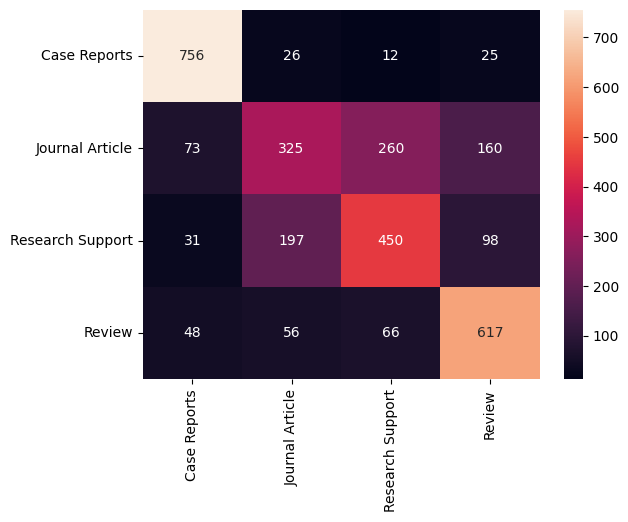

In [285]:
# create a confusion matrix and show it
# there a lot of wrong predictions. Maybe this confusion is because of common words like research. analysis, case...
# it is difficult to distinguish between such categories...
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='g', xticklabels=labels, yticklabels=labels)

###  Testing the model with some imaginary e-mails

In [286]:
# Create sample test messages for testing the model
test_messages = [
    "A randomized controlled trial comparing the effectiveness of two novel antibiotic treatments in patients with bacterial infections showed significant improvement in recovery rates.",
    "This review examines recent findings on immunotherapy in cancer treatment and discusses mechanisms of action, clinical outcomes, and emerging resistance patterns.",
    "Case report: A 45-year-old patient presenting with rare neurological symptoms was diagnosed with a newly identified genetic disorder through comprehensive genetic testing.",
    "We describe the development and clinical validation of a novel diagnostic tool for early detection of cardiovascular disease using machine learning algorithms.",
    "A systematic review and meta-analysis of 150 clinical trials examining the efficacy of various therapeutic interventions in treating autoimmune disorders.",
]

# vectorize the new messages and predict the values
processed_text = vectorizer.transform(test_messages)
results = model.predict_proba(processed_text)

In [287]:
 # switch to decimal format
np.set_printoptions(precision=8, suppress=True)

In [288]:
print("Results for the Naive-Bayes SPAM DETECTION!")
print(labels)
print()

amount = len(results)

for index in range(amount):
    row = results[index]
    result = np.argmax(row)
    result_text = labels[result]
   
    print()
    print(test_messages[index])
    print(row.astype(float))
    print(result_text)

Results for the Naive-Bayes SPAM DETECTION!
['Case Reports', 'Journal Article', 'Research Support', 'Review']


A randomized controlled trial comparing the effectiveness of two novel antibiotic treatments in patients with bacterial infections showed significant improvement in recovery rates.
[0.00000028 0.88248804 0.04468215 0.07282953]
Journal Article

This review examines recent findings on immunotherapy in cancer treatment and discusses mechanisms of action, clinical outcomes, and emerging resistance patterns.
[0.         0.00001048 0.00000853 0.99998099]
Review

Case report: A 45-year-old patient presenting with rare neurological symptoms was diagnosed with a newly identified genetic disorder through comprehensive genetic testing.
[1. 0. 0. 0.]
Case Reports

We describe the development and clinical validation of a novel diagnostic tool for early detection of cardiovascular disease using machine learning algorithms.
[0.00000001 0.14733831 0.27162065 0.58104104]
Review

A systematic 